=== 1. EKSPLORASI DATASET & SANITY CHECK ===

Ringkasan Ketersediaan Data:
       Kelas  Jumlah Gambar  Jumlah Mask
      Normal           1283         1283
   Pneumonia           1271         1271
Tuberculosis           1231         1231


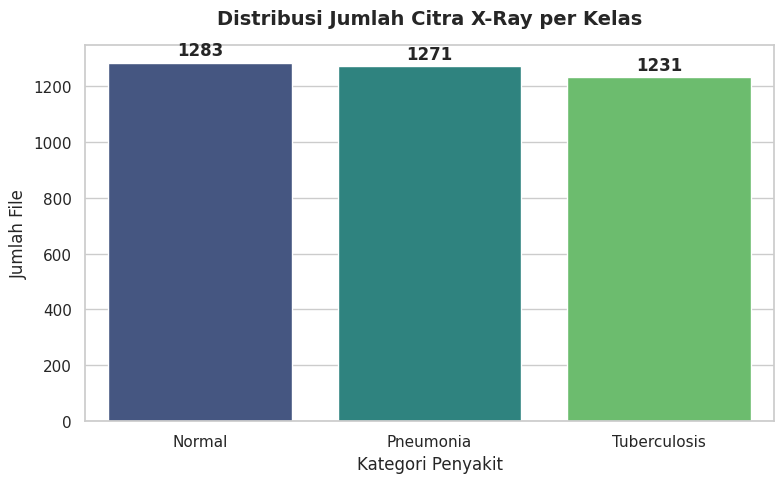


=== 2. VISUALISASI INTEGRITAS MASKING ===


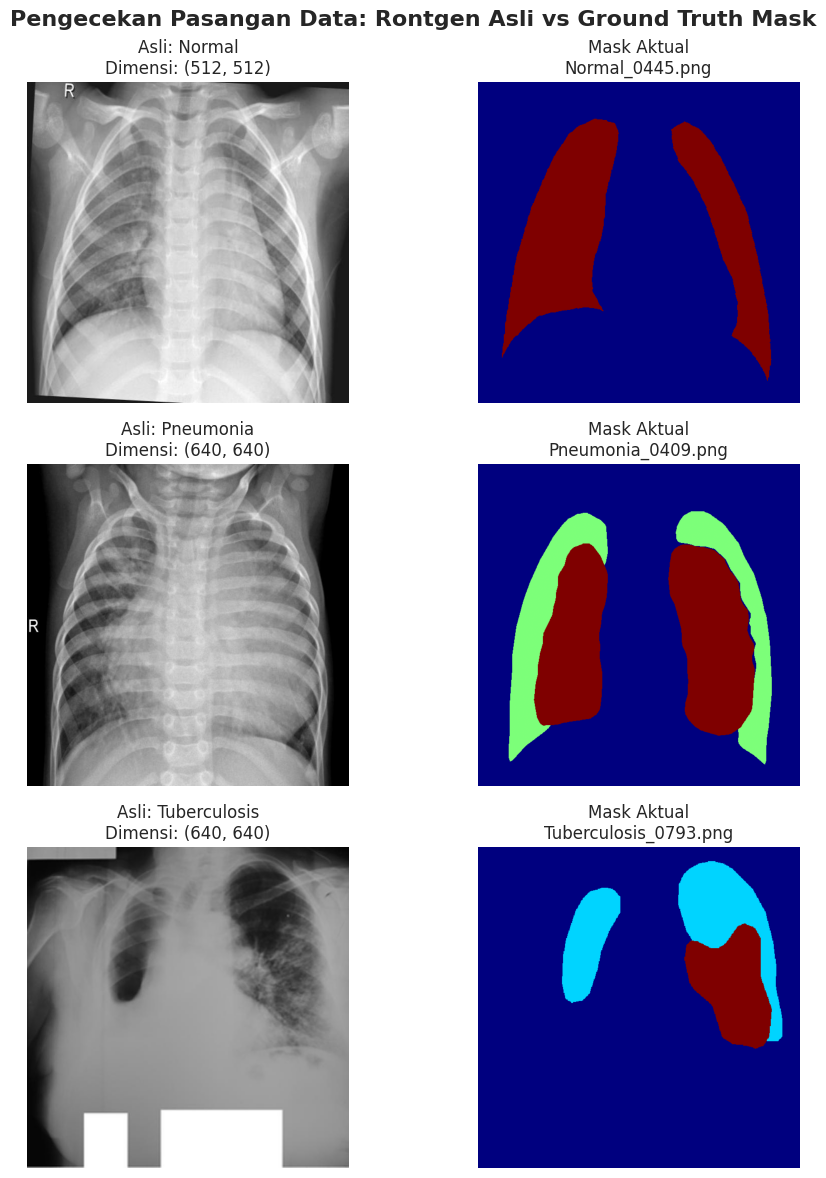

In [1]:
import os
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

print("=== 1. EKSPLORASI DATASET & SANITY CHECK ===")

# Path dataset final
DATASET_DIR = "/kaggle/input/datasets/wildanmiladji/tbcpneumonianormal-lung-dataset-mask-and-origin"
classes = ['Normal', 'Pneumonia', 'Tuberculosis']

# Dictionary untuk menyimpan path file
data_info = {'Kelas': [], 'Jumlah Gambar': [], 'Jumlah Mask': []}
data_paths = {cls: {'images': [], 'masks': []} for cls in classes}

# 1. MENGHITUNG DAN MEMVALIDASI FILE
for cls in classes:
    img_dir = Path(DATASET_DIR) / cls / "images"
    mask_dir = Path(DATASET_DIR) / cls / "masks"
    
    # Ambil semua file .jpg dan .png
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg"))
        data_paths[cls]['images'] = imgs
    else:
        imgs = []
        
    if mask_dir.exists():
        masks = list(mask_dir.glob("*.png"))
        data_paths[cls]['masks'] = masks
    else:
        masks = []
        
    data_info['Kelas'].append(cls)
    data_info['Jumlah Gambar'].append(len(imgs))
    data_info['Jumlah Mask'].append(len(masks))

# Tampilkan dalam bentuk tabel Pandas
df_info = pd.DataFrame(data_info)
print("\nRingkasan Ketersediaan Data:")
print(df_info.to_string(index=False))

# 2. GRAFIK DISTRIBUSI KELAS (VISUALISASI DATASET)
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Kelas', y='Jumlah Gambar', data=df_info, hue='Kelas', palette='viridis', legend=False)

# Tambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Distribusi Jumlah Citra X-Ray per Kelas', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Jumlah File', fontsize=12)
plt.xlabel('Kategori Penyakit', fontsize=12)
plt.tight_layout()
plt.show()

# 3. VISUALISASI SAMPEL ACAK (ASLI VS MASK)
print("\n=== 2. VISUALISASI INTEGRITAS MASKING ===")
fig, axes = plt.subplots(len(classes), 2, figsize=(10, 4 * len(classes)))
fig.suptitle("Pengecekan Pasangan Data: Rontgen Asli vs Ground Truth Mask", fontsize=16, fontweight='bold')

for i, cls in enumerate(classes):
    if data_paths[cls]['images']:
        # Ambil 1 sampel acak
        sample_img_path = random.choice(data_paths[cls]['images'])
        mask_name = sample_img_path.name.replace(".jpg", ".png")
        mask_path = sample_img_path.parent.parent / "masks" / mask_name

        # Plot Gambar Asli
        img = Image.open(sample_img_path)
        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title(f"Asli: {cls}\nDimensi: {img.size}")
        axes[i, 0].axis('off')

        # Plot Mask
        if mask_path.exists():
            mask = Image.open(mask_path)
            # Menggunakan cmap 'jet' agar nilai 0 dan 1 pada mask terlihat sangat kontras
            axes[i, 1].imshow(np.array(mask), cmap="jet")
            axes[i, 1].set_title(f"Mask Aktual\n{mask_name}")
        else:
            axes[i, 1].text(0.5, 0.5, "Mask Tidak Ditemukan", ha='center', va='center')
        axes[i, 1].axis('off')
        
    else:
        axes[i, 0].text(0.5, 0.5, f"Data {cls} Kosong", ha='center', va='center')
        axes[i, 1].text(0.5, 0.5, "-", ha='center', va='center')
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

=== 2. CLEARING DATASET (FIX 1200) & INTEGRITY CHECK ===
[Normal] Ditemukan 1283 pasangan Gambar-Mask yang valid.
Memproses dan CLAHE 1200 pasangan untuk kelas Normal...

[Pneumonia] Ditemukan 1271 pasangan Gambar-Mask yang valid.
Memproses dan CLAHE 1200 pasangan untuk kelas Pneumonia...

[Tuberculosis] Ditemukan 1231 pasangan Gambar-Mask yang valid.
Memproses dan CLAHE 1200 pasangan untuk kelas Tuberculosis...

=== PREVIEW ORIGINAL VS CLAHE ===


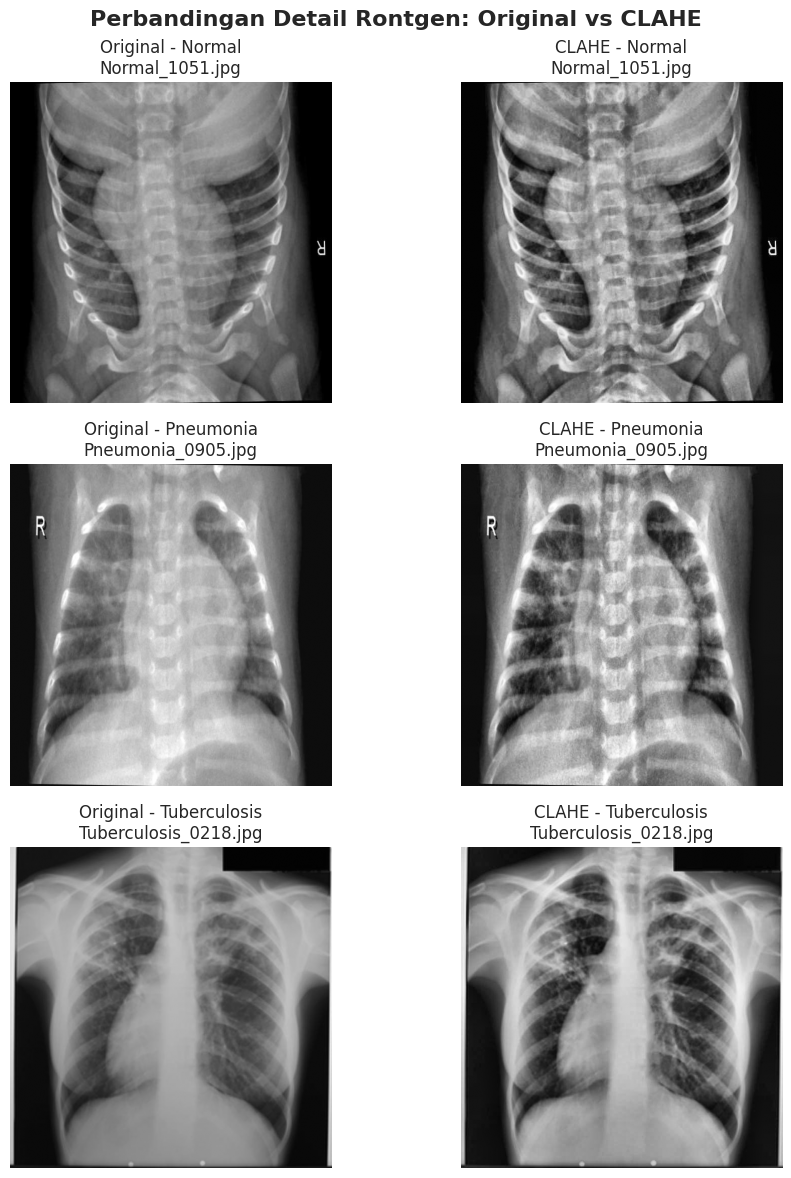

Proses selesai! Data bersih tersimpan di: /kaggle/working/dataset_skripsi_clahe


In [2]:
import os
import cv2
import shutil
import random
import matplotlib.pyplot as plt
from pathlib import Path

print("=== 2. CLEARING DATASET (FIX 1200) & INTEGRITY CHECK ===")

# Path dataset
INPUT_DIR = "/kaggle/input/datasets/wildanmiladji/tbcpneumonianormal-lung-dataset-mask-and-origin"
OUTPUT_DIR = "/kaggle/working/dataset_skripsi_clahe"

# Bersihkan folder output lama kalau ada
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

classes = ['Normal', 'Pneumonia', 'Tuberculosis']
TARGET_SAMPLES = 1200

# Parameter standar CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

for cls in classes:
    img_in_dir = os.path.join(INPUT_DIR, cls, "images")
    mask_in_dir = os.path.join(INPUT_DIR, cls, "masks")
    
    img_out_dir = os.path.join(OUTPUT_DIR, cls, "images")
    mask_out_dir = os.path.join(OUTPUT_DIR, cls, "masks")
    
    os.makedirs(img_out_dir, exist_ok=True)
    os.makedirs(mask_out_dir, exist_ok=True)
    
    # ==============================================================
    # A. INTEGRITY CHECK (Pengecekan Pasangan Gambar & Mask)
    # ==============================================================
    valid_pairs = []
    
    if os.path.exists(img_in_dir) and os.path.exists(mask_in_dir):
        all_imgs = os.listdir(img_in_dir)
        for img_name in all_imgs:
            if img_name.endswith('.jpg') or img_name.endswith('.jpeg'):
                # Cari mask dengan nama yang persis sama tapi format .png
                mask_name = img_name.rsplit('.', 1)[0] + '.png'
                mask_path = os.path.join(mask_in_dir, mask_name)
                
                # Cuma data yang punya mask yang masuk ke list
                if os.path.exists(mask_path):
                    valid_pairs.append((img_name, mask_name))
                    
    print(f"[{cls}] Ditemukan {len(valid_pairs)} pasangan Gambar-Mask yang valid.")
    
    # ==============================================================
    # B. DATA BALANCING (Target Fix 1200)
    # ==============================================================
    if len(valid_pairs) < TARGET_SAMPLES:
        print(f"⚠️ WARNING: Pasangan data {cls} kurang dari {TARGET_SAMPLES}! Hanya memproses {len(valid_pairs)}.")
        selected_pairs = valid_pairs
    else:
        # Acak urutan agar 1200 data yang diambil bener-bener representatif
        random.seed(42)
        random.shuffle(valid_pairs)
        selected_pairs = valid_pairs[:TARGET_SAMPLES]
        
    print(f"Memproses dan CLAHE {len(selected_pairs)} pasangan untuk kelas {cls}...\n")
    
    # ==============================================================
    # C. PREPROCESSING CLAHE & COPY MASK
    # ==============================================================
    for img_name, mask_name in selected_pairs:
        # 1. CLAHE Process
        img_path = os.path.join(img_in_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        clahe_img = clahe.apply(img)
        clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB) # Model butuh 3 channel
        
        # Simpan gambar CLAHE
        out_img_path = os.path.join(img_out_dir, img_name)
        cv2.imwrite(out_img_path, cv2.cvtColor(clahe_rgb, cv2.COLOR_RGB2BGR))
        
        # 2. Copy Mask Pasangannya
        shutil.copy(os.path.join(mask_in_dir, mask_name), os.path.join(mask_out_dir, mask_name))

# ==============================================================
# D. VISUALISASI HASIL PREPROCESSING
# ==============================================================
print("=== PREVIEW ORIGINAL VS CLAHE ===")
fig, axes = plt.subplots(len(classes), 2, figsize=(10, 4 * len(classes)))
fig.suptitle("Perbandingan Detail Rontgen: Original vs CLAHE", fontsize=16, fontweight='bold')

for i, cls in enumerate(classes):
    img_in_dir = os.path.join(INPUT_DIR, cls, "images")
    img_out_dir = os.path.join(OUTPUT_DIR, cls, "images")
    
    if os.path.exists(img_out_dir) and os.listdir(img_out_dir):
        sample_name = random.choice(os.listdir(img_out_dir))
        
        # Load Original
        ori_img = cv2.imread(os.path.join(img_in_dir, sample_name), cv2.IMREAD_GRAYSCALE)
        axes[i, 0].imshow(ori_img, cmap='gray')
        axes[i, 0].set_title(f"Original - {cls}\n{sample_name}")
        axes[i, 0].axis('off')
        
        # Load Hasil CLAHE
        clahe_img = cv2.imread(os.path.join(img_out_dir, sample_name), cv2.IMREAD_GRAYSCALE)
        axes[i, 1].imshow(clahe_img, cmap='gray')
        axes[i, 1].set_title(f"CLAHE - {cls}\n{sample_name}")
        axes[i, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

print(f"Proses selesai! Data bersih tersimpan di: {OUTPUT_DIR}")

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np

# 1. SETUP PATH KE DATASET CLAHE
DATASET_DIR = "/kaggle/working/dataset_skripsi_clahe"
classes = ['Normal', 'Pneumonia', 'Tuberculosis']

all_images = []
all_masks = []
all_labels = [] # Tambahan untuk stratify agar rasio kelas saat split selalu seimbang

print("=== 3. PERSIAPAN DATASET INDUK U-NET ===")
for idx, cls in enumerate(classes):
    img_dir = os.path.join(DATASET_DIR, cls, "images")
    mask_dir = os.path.join(DATASET_DIR, cls, "masks")
    
    if os.path.exists(img_dir) and os.path.exists(mask_dir):
        imgs = sorted(os.listdir(img_dir))
        for img_name in imgs:
            mask_name = img_name.replace(".jpg", ".png")
            if os.path.exists(os.path.join(mask_dir, mask_name)):
                all_images.append(os.path.join(img_dir, img_name))
                all_masks.append(os.path.join(mask_dir, mask_name))
                all_labels.append(idx)

print(f"Total pasangan Gambar & Mask terkumpul: {len(all_images)}")

# 2. BIKIN CUSTOM DATASET PYTORCH
class ClaheLungDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # A. Proses Gambar Asli (CLAHE)
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = img.resize((self.img_size, self.img_size))
        img_arr = np.array(img, dtype=np.float32) / 255.0
        img_arr = np.transpose(img_arr, (2, 0, 1))
        img_tensor = torch.tensor(img_arr, dtype=torch.float32)
        
        # B. Proses Mask (Label)
        mask = Image.open(self.mask_paths[idx])
        mask = mask.resize((self.img_size, self.img_size), Image.Resampling.NEAREST)
        mask_arr = np.array(mask, dtype=np.int64)
        mask_tensor = torch.tensor(mask_arr, dtype=torch.long)
        
        return img_tensor, mask_tensor
print("=== CELL 3C: SKENARIO DATA SPLIT 90:10 ===")
IMG_SIZE = 256
BATCH_SIZE = 16

# Split 90% Train, 10% Validation
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=0.10, random_state=42, stratify=all_labels
)

print(f"Data Training (90%)   : {len(train_imgs)} gambar")
print(f"Data Validation (10%) : {len(val_imgs)} gambar")

train_dataset = ClaheLungDataset(train_imgs, train_masks, img_size=IMG_SIZE)
val_dataset = ClaheLungDataset(val_imgs, val_masks, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity Check
sample_imgs, sample_masks = next(iter(train_loader))
print(f"Bentuk Batch Gambar : {sample_imgs.shape}")

=== 3. PERSIAPAN DATASET INDUK U-NET ===
Total pasangan Gambar & Mask terkumpul: 3600
=== CELL 3C: SKENARIO DATA SPLIT 90:10 ===
Data Training (90%)   : 3240 gambar
Data Validation (10%) : 360 gambar
Bentuk Batch Gambar : torch.Size([16, 3, 256, 256])


In [4]:
# print("=== CELL 3A: SKENARIO DATA SPLIT 70:30 ===")
# IMG_SIZE = 256
# BATCH_SIZE = 16

# # Split 70% Train, 30% Validation
# train_imgs, val_imgs, train_masks, val_masks = train_test_split(
#     all_images, all_masks, test_size=0.30, random_state=42, stratify=all_labels
# )

# print(f"Data Training (70%)   : {len(train_imgs)} gambar")
# print(f"Data Validation (30%) : {len(val_imgs)} gambar")

# train_dataset = ClaheLungDataset(train_imgs, train_masks, img_size=IMG_SIZE)
# val_dataset = ClaheLungDataset(val_imgs, val_masks, img_size=IMG_SIZE)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# # Sanity Check
# sample_imgs, sample_masks = next(iter(train_loader))
# print(f"Bentuk Batch Gambar : {sample_imgs.shape}")

In [5]:
# print("=== CELL 3B: SKENARIO DATA SPLIT 80:20 ===")
# IMG_SIZE = 256
# BATCH_SIZE = 16

# # Split 80% Train, 20% Validation
# train_imgs, val_imgs, train_masks, val_masks = train_test_split(
#     all_images, all_masks, test_size=0.20, random_state=42, stratify=all_labels
# )

# print(f"Data Training (80%)   : {len(train_imgs)} gambar")
# print(f"Data Validation (20%) : {len(val_imgs)} gambar")

# train_dataset = ClaheLungDataset(train_imgs, train_masks, img_size=IMG_SIZE)
# val_dataset = ClaheLungDataset(val_imgs, val_masks, img_size=IMG_SIZE)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# # Sanity Check
# sample_imgs, sample_masks = next(iter(train_loader))
# print(f"Bentuk Batch Gambar : {sample_imgs.shape}")

In [6]:
# print("=== CELL 3C: SKENARIO DATA SPLIT 90:10 ===")
# IMG_SIZE = 256
# BATCH_SIZE = 16

# # Split 90% Train, 10% Validation
# train_imgs, val_imgs, train_masks, val_masks = train_test_split(
#     all_images, all_masks, test_size=0.10, random_state=42, stratify=all_labels
# )

# print(f"Data Training (90%)   : {len(train_imgs)} gambar")
# print(f"Data Validation (10%) : {len(val_imgs)} gambar")

# train_dataset = ClaheLungDataset(train_imgs, train_masks, img_size=IMG_SIZE)
# val_dataset = ClaheLungDataset(val_imgs, val_masks, img_size=IMG_SIZE)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# # Sanity Check
# sample_imgs, sample_masks = next(iter(train_loader))
# print(f"Bentuk Batch Gambar : {sample_imgs.shape}")

In [7]:
print("=== 4. MEMBANGUN ARSITEKTUR U-NET ===")

import torch
import torch.nn as nn

# 1. BLOK DOUBLE CONVOLUTION (Modular block)
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# 2. ARSITEKTUR UTAMA U-NET
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=4):
        # in_channels = 3 (RGB dari CLAHE), out_channels = 4 (Kelas 0, 1, 2, 3 dari Mask)
        super(UNet, self).__init__()
        
        # ENCODER (Jalur Turun - Ekstraksi Fitur)
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # BOTTLENECK (Dasar huruf U)
        self.bottleneck = DoubleConv(512, 1024)
        
        # DECODER (Jalur Naik - Rekonstruksi)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up4 = DoubleConv(1024, 512)
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = DoubleConv(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = DoubleConv(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up1 = DoubleConv(128, 64)
        
        # LAYER OUTPUT
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Proses Encoder + Simpan variabel untuk Skip Connection
        d1 = self.down1(x)
        x = self.pool1(d1)
        
        d2 = self.down2(x)
        x = self.pool2(d2)
        
        d3 = self.down3(x)
        x = self.pool3(d3)
        
        d4 = self.down4(x)
        x = self.pool4(d4)
        
        # Proses Bottleneck
        x = self.bottleneck(x)
        
        # Proses Decoder + Skip Connections (torch.cat)
        x = self.upconv4(x)
        x = torch.cat([x, d4], dim=1)
        x = self.up4(x)
        
        x = self.upconv3(x)
        x = torch.cat([x, d3], dim=1)
        x = self.up3(x)
        
        x = self.upconv2(x)
        x = torch.cat([x, d2], dim=1)
        x = self.up2(x)
        
        x = self.upconv1(x)
        x = torch.cat([x, d1], dim=1)
        x = self.up1(x)
        
        return self.out_conv(x)

# 3. INISIALISASI & SANITY CHECK MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_unet = UNet(in_channels=3, out_channels=4).to(device)

print(f"[*] Arsitektur U-Net berhasil dibangun dan dialokasikan ke: {device}")

# Simulasi dengan tensor kosong untuk memastikan tidak ada error dimensi
dummy_input = torch.randn(1, 3, 256, 256).to(device)
dummy_output = model_unet(dummy_input)

print(f"[*] Shape Input  : {dummy_input.shape}")
print(f"[*] Shape Output : {dummy_output.shape} -> (Batch, Num_Classes, Height, Width)")

=== 4. MEMBANGUN ARSITEKTUR U-NET ===
[*] Arsitektur U-Net berhasil dibangun dan dialokasikan ke: cuda
[*] Shape Input  : torch.Size([1, 3, 256, 256])
[*] Shape Output : torch.Size([1, 4, 256, 256]) -> (Batch, Num_Classes, Height, Width)


In [8]:
# print("=== CELL 5A: SKENARIO U-NET - LR 1e-3 (AGRESIF) ===")

# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# EPOCHS = 25
# LEARNING_RATE = 1e-3 # LR Tinggi

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_unet = model_unet.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(model_unet.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# train_losses, train_accs = [], []
# val_losses, val_accs = [], []
# best_val_loss = float('inf')
# SAVE_PATH = "/kaggle/working/unet_paru_lr_1e3_best.pth"

# # --- LOOP TRAINING ---
# for epoch in range(EPOCHS):
#     model_unet.train()
#     running_train_loss, running_train_correct, total_train_pixels = 0.0, 0, 0
#     train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train LR 1e-3]")
#     for images, masks in train_bar:
#         images, masks = images.to(device), masks.to(device)
#         optimizer.zero_grad()
#         outputs = model_unet(images)
#         loss = criterion(outputs, masks)
#         _, preds = torch.max(outputs, 1) 
#         running_train_correct += (preds == masks).sum().item()
#         total_train_pixels += torch.numel(masks)
#         loss.backward()
#         optimizer.step()
#         running_train_loss += loss.item()
#         temp_acc = (preds == masks).sum().item() / torch.numel(masks)
#         train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{temp_acc*100:.2f}%")
        
#     avg_train_loss = running_train_loss / len(train_loader)
#     avg_train_acc = running_train_correct / total_train_pixels
#     train_losses.append(avg_train_loss)
#     train_accs.append(avg_train_acc)
    
#     model_unet.eval()
#     running_val_loss, running_val_correct, total_val_pixels = 0.0, 0, 0
#     with torch.no_grad():
#         val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid LR 1e-3]")
#         for images, masks in val_bar:
#             images, masks = images.to(device), masks.to(device)
#             outputs = model_unet(images)
#             loss = criterion(outputs, masks)
#             _, preds = torch.max(outputs, 1)
#             running_val_correct += (preds == masks).sum().item()
#             total_val_pixels += torch.numel(masks)
#             running_val_loss += loss.item()
#             temp_acc = (preds == masks).sum().item() / torch.numel(masks)
#             val_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{temp_acc*100:.2f}%")
            
#     avg_val_loss = running_val_loss / len(val_loader)
#     avg_val_acc = running_val_correct / total_val_pixels
#     val_losses.append(avg_val_loss)
#     val_accs.append(avg_val_acc)
    
#     print(f"-> Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         torch.save(model_unet.state_dict(), SAVE_PATH)

# # ==============================================================
# # VISUALISASI TRANSPARANSI TRAINING (BUKTI SKRIPSI)
# # ==============================================================
# print("\n=== MEMBUAT GRAFIK TRANSPARANSI PEMBELAJARAN ===")
# plt.figure(figsize=(14, 5))

# # Grafik 1: Pergerakan Loss
# plt.subplot(1, 2, 1)
# plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='blue', marker='o', markersize=4)
# plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='red', marker='s', markersize=4)
# plt.title('Kurva Evaluasi Error (Loss) - Skenario LR 1e-3', fontsize=12, fontweight='bold')
# plt.xlabel('Epoch', fontsize=10)
# plt.ylabel('Nilai Cross-Entropy Loss', fontsize=10)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)

# # Grafik 2: Pergerakan Akurasi Piksel
# plt.subplot(1, 2, 2)
# plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in train_accs], label='Training Accuracy', color='blue', marker='o', markersize=4)
# plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in val_accs], label='Validation Accuracy', color='green', marker='^', markersize=4)
# plt.title('Kurva Akurasi Segmentasi - Skenario LR 1e-3', fontsize=12, fontweight='bold')
# plt.xlabel('Epoch', fontsize=10)
# plt.ylabel('Akurasi (%)', fontsize=10)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

=== CELL 5B: SKENARIO U-NET - LR 1e-4 (BASELINE) ===


Epoch 1/25 [Valid LR 1e-4]: 100%|██████████| 23/23 [00:09<00:00,  2.52it/s, acc=90.50%, loss=0.4514]


-> Epoch 1 | Train Loss: 0.6416 | Val Loss: 0.4449


Epoch 2/25 [Valid LR 1e-4]: 100%|██████████| 23/23 [00:09<00:00,  2.53it/s, acc=91.60%, loss=0.3261]


-> Epoch 2 | Train Loss: 0.3651 | Val Loss: 0.2987


...

-> Epoch 23 | Train Loss: 0.0714 | Val Loss: 0.1540


Epoch 24/25 [Valid LR 1e-4]: 100%|██████████| 23/23 [00:09<00:00,  2.51it/s, acc=94.83%, loss=0.1621]


-> Epoch 24 | Train Loss: 0.0719 | Val Loss: 0.1567


Epoch 25/25 [Valid LR 1e-4]: 100%|██████████| 23/23 [00:09<00:00,  2.52it/s, acc=94.78%, loss=0.1859]


-> Epoch 25 | Train Loss: 0.0660 | Val Loss: 0.1611

=== MEMBUAT GRAFIK TRANSPARANSI PEMBELAJARAN ===


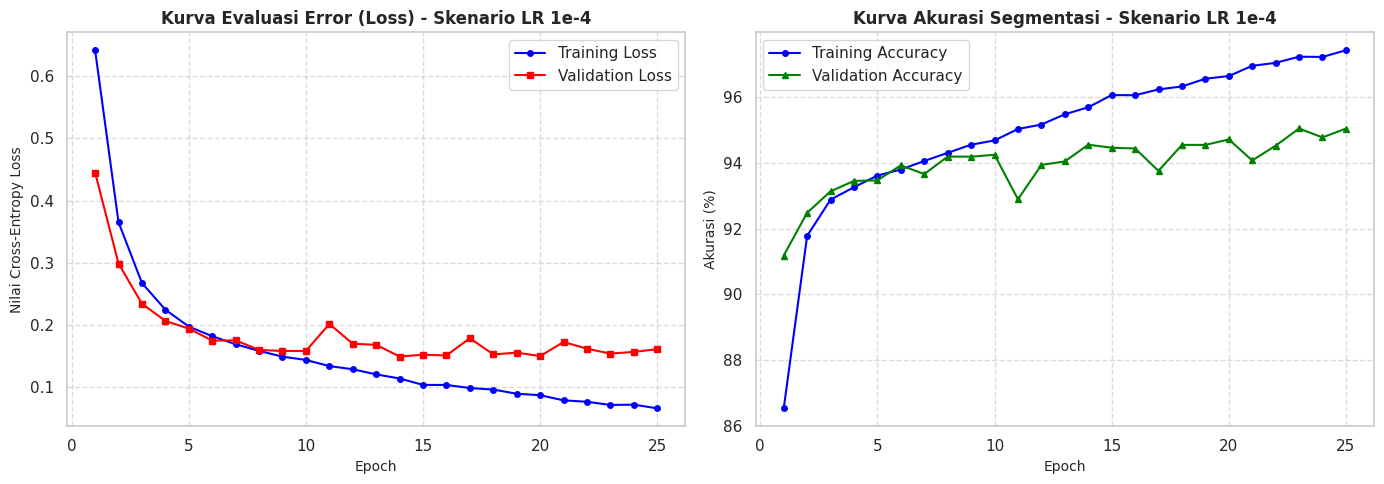

In [9]:
print("=== CELL 5B: SKENARIO U-NET - LR 1e-4 (BASELINE) ===")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

EPOCHS = 25
LEARNING_RATE = 1e-4 # LR Standar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_unet = model_unet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_unet.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_loss = float('inf')
SAVE_PATH = "/kaggle/working/unet_paru_lr_1e4_best.pth"

# --- LOOP TRAINING ---
for epoch in range(EPOCHS):
    model_unet.train()
    running_train_loss, running_train_correct, total_train_pixels = 0.0, 0, 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train LR 1e-4]")
    for images, masks in train_bar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model_unet(images)
        loss = criterion(outputs, masks)
        _, preds = torch.max(outputs, 1) 
        running_train_correct += (preds == masks).sum().item()
        total_train_pixels += torch.numel(masks)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        temp_acc = (preds == masks).sum().item() / torch.numel(masks)
        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{temp_acc*100:.2f}%")
        
    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_acc = running_train_correct / total_train_pixels
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    
    model_unet.eval()
    running_val_loss, running_val_correct, total_val_pixels = 0.0, 0, 0
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid LR 1e-4]")
        for images, masks in val_bar:
            images, masks = images.to(device), masks.to(device)
            outputs = model_unet(images)
            loss = criterion(outputs, masks)
            _, preds = torch.max(outputs, 1)
            running_val_correct += (preds == masks).sum().item()
            total_val_pixels += torch.numel(masks)
            running_val_loss += loss.item()
            temp_acc = (preds == masks).sum().item() / torch.numel(masks)
            val_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{temp_acc*100:.2f}%")
            
    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_acc = running_val_correct / total_val_pixels
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)
    
    print(f"-> Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_unet.state_dict(), SAVE_PATH)

# ==============================================================
# VISUALISASI TRANSPARANSI TRAINING (BUKTI SKRIPSI)
# ==============================================================
print("\n=== MEMBUAT GRAFIK TRANSPARANSI PEMBELAJARAN ===")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='red', marker='s', markersize=4)
plt.title('Kurva Evaluasi Error (Loss) - Skenario LR 1e-4', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Nilai Cross-Entropy Loss', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in train_accs], label='Training Accuracy', color='blue', marker='o', markersize=4)
plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in val_accs], label='Validation Accuracy', color='green', marker='^', markersize=4)
plt.title('Kurva Akurasi Segmentasi - Skenario LR 1e-4', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Akurasi (%)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [10]:
# print("=== CELL 5C: SKENARIO U-NET - LR 1e-5 (KONSERVATIF) ===")

# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# EPOCHS = 25
# LEARNING_RATE = 1e-5 # LR Kecil

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_unet = model_unet.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(model_unet.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# train_losses, train_accs = [], []
# val_losses, val_accs = [], []
# best_val_loss = float('inf')
# SAVE_PATH = "/kaggle/working/unet_paru_lr_1e5_best.pth"

# # --- LOOP TRAINING ---
# for epoch in range(EPOCHS):
#     model_unet.train()
#     running_train_loss, running_train_correct, total_train_pixels = 0.0, 0, 0
#     train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train LR 1e-5]")
#     for images, masks in train_bar:
#         images, masks = images.to(device), masks.to(device)
#         optimizer.zero_grad()
#         outputs = model_unet(images)
#         loss = criterion(outputs, masks)
#         _, preds = torch.max(outputs, 1) 
#         running_train_correct += (preds == masks).sum().item()
#         total_train_pixels += torch.numel(masks)
#         loss.backward()
#         optimizer.step()
#         running_train_loss += loss.item()
#         temp_acc = (preds == masks).sum().item() / torch.numel(masks)
#         train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{temp_acc*100:.2f}%")
        
#     avg_train_loss = running_train_loss / len(train_loader)
#     avg_train_acc = running_train_correct / total_train_pixels
#     train_losses.append(avg_train_loss)
#     train_accs.append(avg_train_acc)
    
#     model_unet.eval()
#     running_val_loss, running_val_correct, total_val_pixels = 0.0, 0, 0
#     with torch.no_grad():
#         val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid LR 1e-5]")
#         for images, masks in val_bar:
#             images, masks = images.to(device), masks.to(device)
#             outputs = model_unet(images)
#             loss = criterion(outputs, masks)
#             _, preds = torch.max(outputs, 1)
#             running_val_correct += (preds == masks).sum().item()
#             total_val_pixels += torch.numel(masks)
#             running_val_loss += loss.item()
#             temp_acc = (preds == masks).sum().item() / torch.numel(masks)
#             val_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{temp_acc*100:.2f}%")
            
#     avg_val_loss = running_val_loss / len(val_loader)
#     avg_val_acc = running_val_correct / total_val_pixels
#     val_losses.append(avg_val_loss)
#     val_accs.append(avg_val_acc)
    
#     print(f"-> Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         torch.save(model_unet.state_dict(), SAVE_PATH)

# # ==============================================================
# # VISUALISASI TRANSPARANSI TRAINING (BUKTI SKRIPSI)
# # ==============================================================
# print("\n=== MEMBUAT GRAFIK TRANSPARANSI PEMBELAJARAN ===")
# plt.figure(figsize=(14, 5))

# plt.subplot(1, 2, 1)
# plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='blue', marker='o', markersize=4)
# plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='red', marker='s', markersize=4)
# plt.title('Kurva Evaluasi Error (Loss) - Skenario LR 1e-5', fontsize=12, fontweight='bold')
# plt.xlabel('Epoch', fontsize=10)
# plt.ylabel('Nilai Cross-Entropy Loss', fontsize=10)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)

# plt.subplot(1, 2, 2)
# plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in train_accs], label='Training Accuracy', color='blue', marker='o', markersize=4)
# plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in val_accs], label='Validation Accuracy', color='green', marker='^', markersize=4)
# plt.title('Kurva Akurasi Segmentasi - Skenario LR 1e-5', fontsize=12, fontweight='bold')
# plt.xlabel('Epoch', fontsize=10)
# plt.ylabel('Akurasi (%)', fontsize=10)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

=== 6. EVALUASI METRIK (DICE & IoU) & VISUALISASI U-NET ===
[*] Menghitung metrik untuk seluruh data validasi...

         LAPORAN METRIK SEGMENTASI U-NET          
Kelas           | IoU Score       | Dice Score     
--------------------------------------------------
Background      | 0.9593          | 0.9792
Paru/Normal     | 0.7945          | 0.8851
Pneumonia       | 0.5942          | 0.7435
TBC             | 0.6570          | 0.7878
Mean (mIoU)     | 0.7512          | 0.8489

[*] Menyiapkan visualisasi perbandingan...


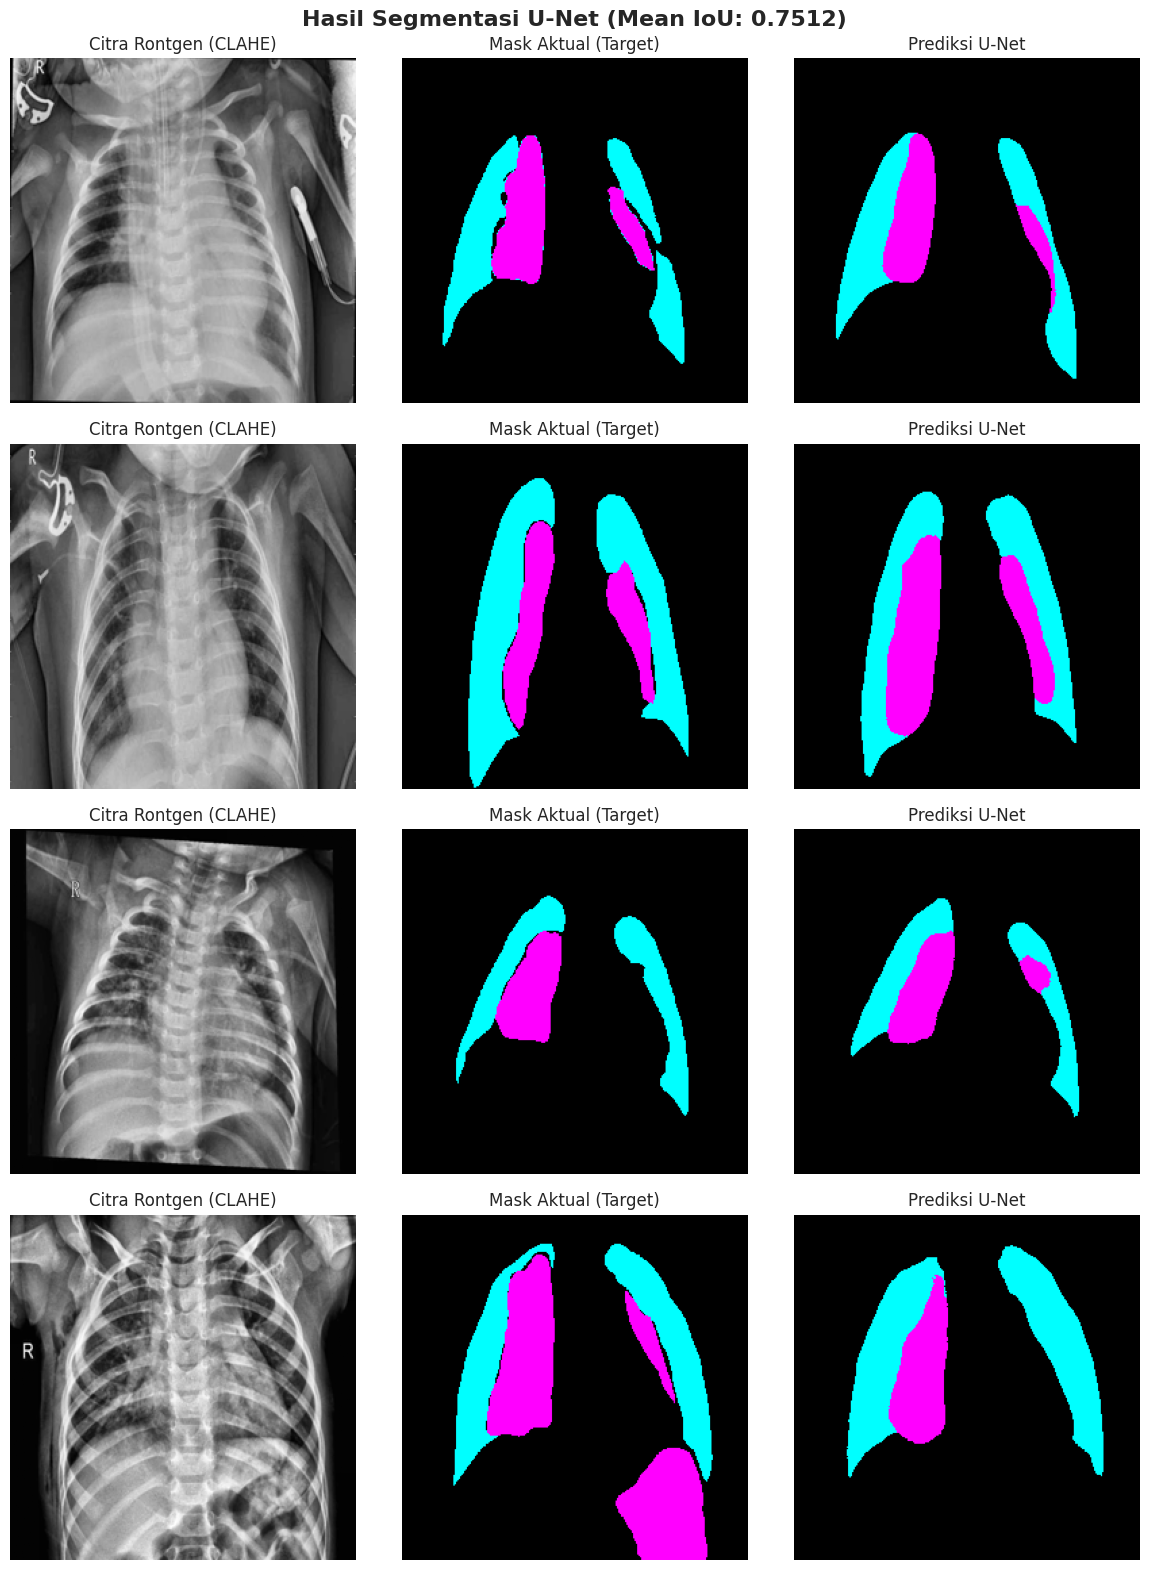

In [11]:
print("=== 6. EVALUASI METRIK (DICE & IoU) & VISUALISASI U-NET ===")

import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP & LOAD MODEL TERBAIK
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Karena sebelumnya pakai skenario 5C (1e-5), path-nya otomatis mengarah ke sini
BEST_MODEL_PATH = "/kaggle/working/unet_paru_lr_1e4_best.pth" 

model_unet.load_state_dict(torch.load(BEST_MODEL_PATH))
model_unet.eval()

# 2. FUNGSI PERHITUNGAN DICE & IOU
# Rumus IoU  = Area of Overlap / Area of Union
# Rumus Dice = 2 * Area of Overlap / Total Pixels in both arrays
def calculate_iou_dice(preds, targets, num_classes=4):
    ious = np.zeros(num_classes)
    dices = np.zeros(num_classes)
    
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = targets == cls
        
        intersection = (pred_inds & target_inds).sum().item()
        union = pred_inds.sum().item() + target_inds.sum().item() - intersection
        
        if union == 0:
            # Jika kelas ini tidak ada di gambar dan tidak ditebak model, anggap sempurna (1.0)
            ious[cls] = 1.0 
            dices[cls] = 1.0
        else:
            ious[cls] = intersection / union
            dices[cls] = (2. * intersection) / (pred_inds.sum().item() + target_inds.sum().item())
            
    return ious, dices

# 3. MENGHITUNG METRIK UNTUK SELURUH DATA VALIDASI
print("[*] Menghitung metrik untuk seluruh data validasi...")
all_ious = []
all_dices = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model_unet(images)
        _, preds = torch.max(outputs, 1)
        
        # Hitung untuk batch ini
        batch_ious, batch_dices = calculate_iou_dice(preds, masks, num_classes=4)
        all_ious.append(batch_ious)
        all_dices.append(batch_dices)

# Rata-ratakan hasil dari semua batch
mean_ious = np.mean(all_ious, axis=0)
mean_dices = np.mean(all_dices, axis=0)

# Print Laporan ala Skripsi
class_names = ['Background', 'Paru/Normal', 'Pneumonia', 'TBC']
print("\n" + "="*50)
print(f"{'LAPORAN METRIK SEGMENTASI U-NET':^50}")
print("="*50)
print(f"{'Kelas':<15} | {'IoU Score':<15} | {'Dice Score':<15}")
print("-" * 50)
for i in range(4):
    print(f"{class_names[i]:<15} | {mean_ious[i]:.4f}          | {mean_dices[i]:.4f}")
print("=" * 50)
print(f"{'Mean (mIoU)':<15} | {np.mean(mean_ious):.4f}          | {np.mean(mean_dices):.4f}")
print("=" * 50 + "\n")

# 4. VISUALISASI HASIL PEMOTONGAN
print("[*] Menyiapkan visualisasi perbandingan...")
COLOR_MAP = np.array([
    [0, 0, 0],         # 0: Background (Hitam)
    [0, 255, 255],     # 1: Paru (Cyan)
    [255, 0, 255],     # 2: Pneumonia (Magenta)
    [255, 255, 0]      # 3: TBC (Kuning)
], dtype=np.uint8)

# Ambil 1 batch secara acak dari dataloader
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model_unet(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.cpu().numpy()

num_samples = 4
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
fig.suptitle(f"Hasil Segmentasi U-Net (Mean IoU: {np.mean(mean_ious):.4f})", fontsize=16, fontweight='bold')

for i in range(num_samples):
    # Gambar Asli (Transpose dari Channel-First ke format RGB Matplotlib)
    img_display = np.transpose(images[i], (1, 2, 0))
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title("Citra Rontgen (CLAHE)")
    axes[i, 0].axis('off')
    
    # Mask Asli (Ground Truth)
    gt_color = COLOR_MAP[masks[i]]
    axes[i, 1].imshow(gt_color)
    axes[i, 1].set_title("Mask Aktual (Target)")
    axes[i, 1].axis('off')
    
    # Prediksi U-Net
    pred_color = COLOR_MAP[preds[i]]
    axes[i, 2].imshow(pred_color)
    axes[i, 2].set_title("Prediksi U-Net")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [12]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np

print("=== 7. RANCANG BANGUN ViT + INJEKSI PRE-TRAINED IMAGENET (FULL) ===")

# ==============================================================
# 1. SETUP DATA KLASIFIKASI & SPLIT
# ==============================================================
DATASET_DIR = "/kaggle/working/dataset_skripsi_clahe"
class_mapping = {'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}

vit_images = []
vit_labels = []

for cls_name, cls_idx in class_mapping.items():
    img_dir = os.path.join(DATASET_DIR, cls_name, "images")
    if os.path.exists(img_dir):
        for img_name in os.listdir(img_dir):
            vit_images.append(os.path.join(img_dir, img_name))
            vit_labels.append(cls_idx)

# Baseline Split 80:20 yang stabil untuk klasifikasi
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    vit_images, vit_labels, test_size=0.2, random_state=42, stratify=vit_labels
)

print(f"Total Data Train ViT : {len(train_imgs)}")
print(f"Total Data Valid ViT : {len(val_imgs)}")

# ==============================================================
# 2. CUSTOM DATASET: U-NET MASKING -> ViT INPUT
# ==============================================================
class ViTLungDataset(Dataset):
    def __init__(self, image_paths, labels, unet_model, device, img_size=224):
        self.image_paths = image_paths
        self.labels = labels
        self.unet = unet_model
        self.device = device
        self.img_size = img_size
        
        # Transformasi wajib standar ImageNet untuk ViT
        self.vit_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # A. Load Gambar CLAHE asli
        img_pil = Image.open(self.image_paths[idx]).convert("RGB")
        
        # B. Siapkan input untuk prediksi mask U-Net (256x256)
        unet_input = img_pil.resize((256, 256))
        unet_arr = np.array(unet_input, dtype=np.float32) / 255.0
        unet_arr = np.transpose(unet_arr, (2, 0, 1))
        unet_tensor = torch.tensor(unet_arr, dtype=torch.float32).unsqueeze(0).to(self.device)
        
        # C. Prediksi Mask pakai U-Net
        with torch.no_grad():
            unet_output = self.unet(unet_tensor)
            _, pred_mask = torch.max(unet_output, 1)
            pred_mask = pred_mask.squeeze(0).cpu().numpy() # Shape: (256, 256)
            
        # D. Eksekusi Isolasi ROI
        binary_mask = (pred_mask > 0).astype(np.uint8)
        mask_pil = Image.fromarray(binary_mask * 255).resize(img_pil.size, Image.Resampling.NEAREST)
        mask_np = np.expand_dims(np.array(mask_pil) / 255.0, axis=-1)
        
        img_np = np.array(img_pil)
        masked_img_np = (img_np * mask_np).astype(np.uint8)
        masked_img_pil = Image.fromarray(masked_img_np)
        
        # E. Ubah ke format tensor ViT
        vit_tensor = self.vit_transform(masked_img_pil)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return vit_tensor, label_tensor

# ==============================================================
# 3. RANCANG BANGUN ARSITEKTUR HYBRID ViT
# ==============================================================
class ViTSkripsi(nn.Module):
    def __init__(self, num_classes=3):
        super(ViTSkripsi, self).__init__()
        
        print("[*] Mengunduh & membedah bobot ImageNet dari Google Brain...")
        # A. Muat model ViT utuh beserta bobot ImageNet-nya
        vit_pretrained = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        
        # B. EKSTRAKSI KOMPONEN LAYER
        self.patch_embed = vit_pretrained.conv_proj 
        self.class_token = vit_pretrained.class_token
        self.pos_embedding = vit_pretrained.encoder.pos_embedding
        self.transformer_encoder = vit_pretrained.encoder
        
        # C. BANGUN LAYER OUTPUT BARU
        emb_size = 768 # Dimensi standar ViT Base
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, num_classes)
        )

    def forward(self, x):
        # 1. Pemotongan Patch (16x16)
        x = self.patch_embed(x) 
        x = x.flatten(2).transpose(1, 2)
        
        # 2. Sisipkan Token [CLS] dan Posisi
        b = x.shape[0]
        batch_class_token = self.class_token.expand(b, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = x + self.pos_embedding
        
        # 3. Proses Transformer Encoder
        x = self.transformer_encoder(x)
        
        # 4. Ambil kesimpulan dari Token [CLS]
        cls_output = x[:, 0]
        
        return self.mlp_head(cls_output)

# ==============================================================
# 4. INISIALISASI MODEL & DATALOADER
# ==============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Panggil U-Net terbaik untuk fungsi DataLoader
# (Pastikan nama filenya sesuai dengan skenario U-Net yang kamu pilih sebelumnya)
unet_for_vit = UNet(in_channels=3, out_channels=4).to(device)
unet_for_vit.load_state_dict(torch.load("/kaggle/working/unet_paru_lr_1e4_best.pth"))
unet_for_vit.eval() # Freeze U-Net

# Setup DataLoader
train_dataset_vit = ViTLungDataset(train_imgs, train_labels, unet_for_vit, device)
val_dataset_vit = ViTLungDataset(val_imgs, val_labels, unet_for_vit, device)

train_loader_vit = DataLoader(train_dataset_vit, batch_size=16, shuffle=True)
val_loader_vit = DataLoader(val_dataset_vit, batch_size=16, shuffle=False)

# Panggil arsitektur ViT rakitan kita
model_vit = ViTSkripsi(num_classes=3).to(device)

print(f"[*] Arsitektur Hybrid ViT-B/16 berhasil dirakit di {device}!")

# Sanity Check untuk memastikan dimensi aman
dummy_input = torch.randn(1, 3, 224, 224).to(device)
dummy_output = model_vit(dummy_input)
print(f"[*] Shape Input ViT  : {dummy_input.shape}")
print(f"[*] Shape Output ViT : {dummy_output.shape} -> (Batch, Num_Classes)")

=== 7. RANCANG BANGUN ViT + INJEKSI PRE-TRAINED IMAGENET (FULL) ===
Total Data Train ViT : 2880
Total Data Valid ViT : 720
[*] Mengunduh & membedah bobot ImageNet dari Google Brain...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 232MB/s]


[*] Arsitektur Hybrid ViT-B/16 berhasil dirakit di cuda!
[*] Shape Input ViT  : torch.Size([1, 3, 224, 224])
[*] Shape Output ViT : torch.Size([1, 3]) -> (Batch, Num_Classes)


=== 8. FINE-TUNING VISION TRANSFORMER (KLASIFIKASI PENYAKIT) ===


Epoch 1/20 [Valid ViT]: 100%|██████████| 45/45 [00:34<00:00,  1.30it/s, acc=98.89%, loss=0.5207]


-> Epoch 1 | Train Loss: 0.1854 (Acc: 93.65%) | Val Loss: 0.0593 (Acc: 98.89%)
🔥 REKOR BARU! Akurasi naik jadi 98.89%. Bobot ViT berhasil disimpan!



Epoch 2/20 [Valid ViT]: 100%|██████████| 45/45 [00:34<00:00,  1.30it/s, acc=97.36%, loss=0.5712]


-> Epoch 2 | Train Loss: 0.0700 (Acc: 97.81%) | Val Loss: 0.0967 (Acc: 97.36%)
⚠️ Akurasi belum lewat rekor (98.89%). Skip save...



...

-> Epoch 18 | Train Loss: 0.0033 (Acc: 99.86%) | Val Loss: 0.1267 (Acc: 98.61%)
⚠️ Akurasi belum lewat rekor (99.03%). Skip save...



Epoch 19/20 [Valid ViT]: 100%|██████████| 45/45 [00:34<00:00,  1.30it/s, acc=98.61%, loss=0.7241]


-> Epoch 19 | Train Loss: 0.0032 (Acc: 99.76%) | Val Loss: 0.1298 (Acc: 98.61%)
⚠️ Akurasi belum lewat rekor (99.03%). Skip save...



Epoch 20/20 [Valid ViT]: 100%|██████████| 45/45 [00:34<00:00,  1.31it/s, acc=98.47%, loss=0.8071]


-> Epoch 20 | Train Loss: 0.0028 (Acc: 99.86%) | Val Loss: 0.0992 (Acc: 98.47%)
⚠️ Akurasi belum lewat rekor (99.03%). Skip save...


=== TRAINING VISION TRANSFORMER SELESAI ===
File bobot klasifikasi terbaik tersimpan aman di: /kaggle/working/vit_skripsi_multiclass_bestV2.pth

=== MEMBUAT GRAFIK KURVA PEMBELAJARAN ViT ===


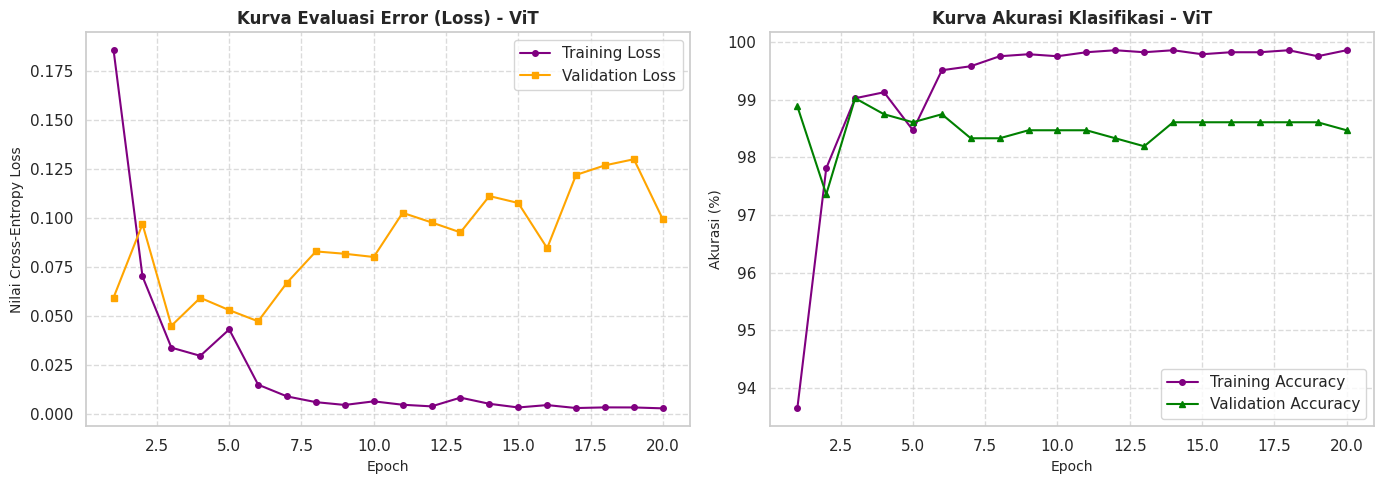

In [13]:
print("=== 8. FINE-TUNING VISION TRANSFORMER (KLASIFIKASI PENYAKIT) ===")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==============================================================
# 1. SETUP HYPERPARAMETER & OPTIMIZER
# ==============================================================
EPOCHS = 20
LEARNING_RATE = 3e-5 # Sangat krusial: LR kecil agar pre-trained ImageNet tidak hancur

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit = model_vit.to(device)

# Loss Function & Optimizer (AdamW direkomendasikan untuk Transformer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_vit.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

train_losses, train_accs = [], []
val_losses, val_accs = [], []

# Auto-save berdasarkan Akurasi Validasi Tertinggi (Bukan Loss, karena fokus ke klasifikasi)
best_val_acc = 0.0
SAVE_PATH_VIT = "/kaggle/working/vit_skripsi_multiclass_bestV2.pth"

# ==============================================================
# 2. MULAI LOOP TRAINING ViT
# ==============================================================
for epoch in range(EPOCHS):
    # --- FASE TRAINING ---
    model_vit.train()
    running_loss, running_corrects, total_samples = 0.0, 0, 0
    
    train_bar = tqdm(train_loader_vit, desc=f"Epoch {epoch+1}/{EPOCHS} [Train ViT]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_vit(images)
        loss = criterion(outputs, labels)
        
        _, preds = torch.max(outputs, 1)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_samples += images.size(0)
        
        current_acc = (running_corrects.item() / total_samples) * 100
        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2f}%")
        
    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects.double() / total_samples
    
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc.item())
    
    # --- FASE VALIDATION ---
    model_vit.eval()
    running_val_loss, running_val_corrects, total_val_samples = 0.0, 0, 0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader_vit, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid ViT]")
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model_vit(images)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            
            running_val_loss += loss.item() * images.size(0)
            running_val_corrects += torch.sum(preds == labels.data)
            total_val_samples += images.size(0)
            
            current_val_acc = (running_val_corrects.item() / total_val_samples) * 100
            val_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_val_acc:.2f}%")
            
    epoch_val_loss = running_val_loss / total_val_samples
    epoch_val_acc = running_val_corrects.double() / total_val_samples
    
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc.item())
    
    print(f"-> Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} (Acc: {epoch_train_acc*100:.2f}%) | Val Loss: {epoch_val_loss:.4f} (Acc: {epoch_val_acc*100:.2f}%)")
    
    # --- SISTEM AUTO-SAVE MODEL TERBAIK ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model_vit.state_dict(), SAVE_PATH_VIT)
        print(f"🔥 REKOR BARU! Akurasi naik jadi {best_val_acc*100:.2f}%. Bobot ViT berhasil disimpan!\n")
    else:
        print(f"⚠️ Akurasi belum lewat rekor ({best_val_acc*100:.2f}%). Skip save...\n")

print("\n=== TRAINING VISION TRANSFORMER SELESAI ===")
print(f"File bobot klasifikasi terbaik tersimpan aman di: {SAVE_PATH_VIT}")

# ==============================================================
# 3. VISUALISASI TRANSPARANSI PEMBELAJARAN ViT
# ==============================================================
print("\n=== MEMBUAT GRAFIK KURVA PEMBELAJARAN ViT ===")
plt.figure(figsize=(14, 5))

# Grafik 1: Pergerakan Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='purple', marker='o', markersize=4)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='orange', marker='s', markersize=4)
plt.title('Kurva Evaluasi Error (Loss) - ViT', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Nilai Cross-Entropy Loss', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Grafik 2: Pergerakan Akurasi
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in train_accs], label='Training Accuracy', color='purple', marker='o', markersize=4)
plt.plot(range(1, EPOCHS+1), [acc * 100 for acc in val_accs], label='Validation Accuracy', color='green', marker='^', markersize=4)
plt.title('Kurva Akurasi Klasifikasi - ViT', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Akurasi (%)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

=== 9. EVALUASI METRIK KLASIFIKASI & CONFUSION MATRIX ViT ===
[*] Melakukan inferensi pada seluruh data validasi...

     LAPORAN HASIL KLASIFIKASI VISION TRANSFORMER (ViT)     
              precision    recall  f1-score   support

      Normal     0.9957    0.9750    0.9853       240
   Pneumonia     0.9917    1.0000    0.9959       240
Tuberculosis     0.9835    0.9958    0.9896       240

    accuracy                         0.9903       720
   macro avg     0.9903    0.9903    0.9903       720
weighted avg     0.9903    0.9903    0.9903       720


[*] Membuat grafik Confusion Matrix untuk naskah skripsi...


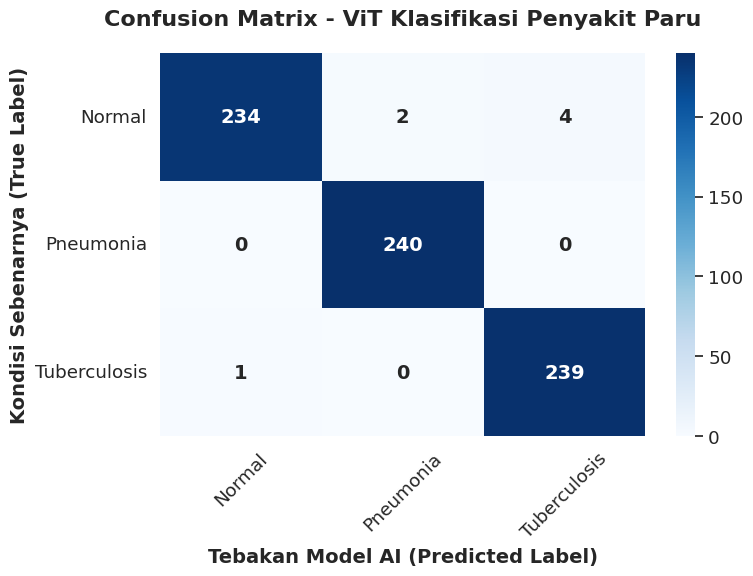

In [14]:
print("=== 9. EVALUASI METRIK KLASIFIKASI & CONFUSION MATRIX ViT ===")

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. SETUP & LOAD BOBOT ViT TERBAIK
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_VIT_PATH = "/kaggle/working/vit_skripsi_multiclass_bestV2.pth"

# Pastikan model_vit sudah diinisialisasi di Cell 7 sebelumnya
model_vit.load_state_dict(torch.load(BEST_VIT_PATH))
model_vit.eval()

# 2. PROSES PENGUMPULAN PREDIKSI
all_preds = []
all_labels = []

print("[*] Melakukan inferensi pada seluruh data validasi...")
with torch.no_grad():
    for images, labels in val_loader_vit:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_vit(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Definisi nama kelas sesuai urutan
class_names = ['Normal', 'Pneumonia', 'Tuberculosis']

# ==============================================================
# 3. LAPORAN METRIK (CLASSIFICATION REPORT)
# ==============================================================
print("\n" + "="*60)
print(f"{'LAPORAN HASIL KLASIFIKASI VISION TRANSFORMER (ViT)':^60}")
print("="*60)
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)
print("="*60)

# ==============================================================
# 4. VISUALISASI CONFUSION MATRIX
# ==============================================================
print("\n[*] Membuat grafik Confusion Matrix untuk naskah skripsi...")

# Hitung nilai matriks
cm = confusion_matrix(all_labels, all_preds)

# Buat plot visualisasi
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2) # Perbesar font biar jelas pas di-screenshot

# Gunakan heatmap seaborn dengan warna biru medis (Blues)
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                 xticklabels=class_names, yticklabels=class_names,
                 annot_kws={"size": 14, "weight": "bold"})

# Atur label sumbu
plt.title('Confusion Matrix - ViT Klasifikasi Penyakit Paru', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tebakan Model AI (Predicted Label)', fontsize=14, fontweight='bold')
plt.ylabel('Kondisi Sebenarnya (True Label)', fontsize=14, fontweight='bold')

# Rotasi label agar lebih rapi
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

=== 10. EVALUASI TINGKAT KEYAKINAN MODEL (KURVA ROC-AUC) ===
[*] Menghitung probabilitas prediksi untuk setiap kelas...

[*] Membuat grafik Multi-class ROC-AUC...


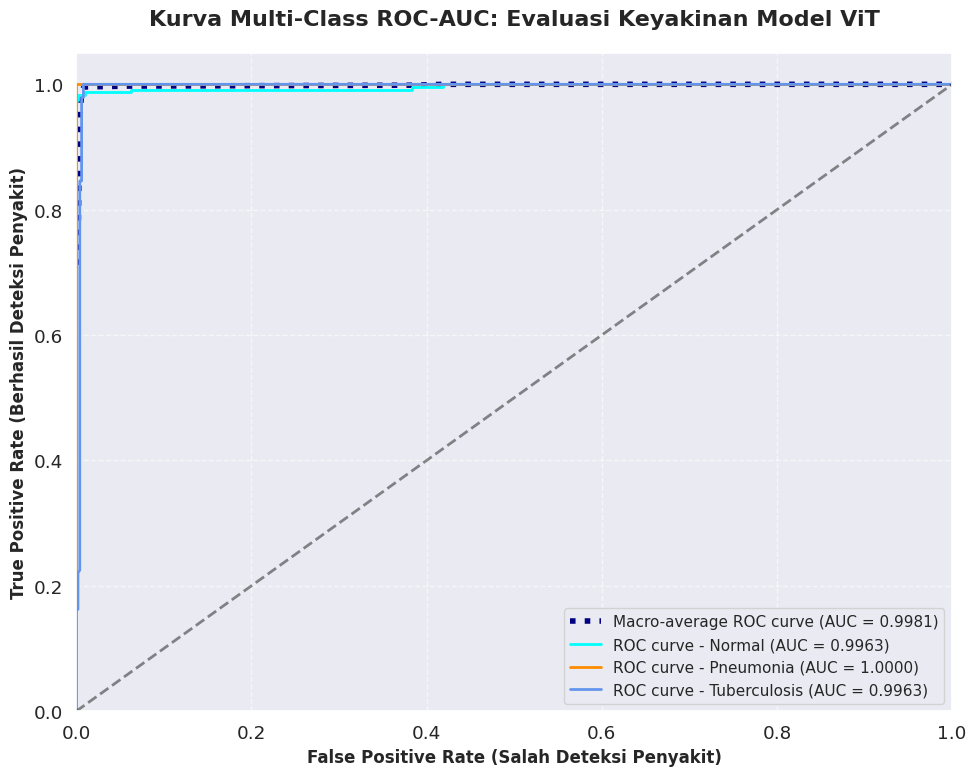


Penjelasan Singkat untuk Bab 4:
- Nilai AUC (Area Under Curve) berkisar antara 0.5 hingga 1.0.
- Semakin nilai AUC mendekati 1.0, artinya model semakin ahli (tidak menebak secara buta) dalam membedakan kelas tersebut.


In [15]:
print("=== 10. EVALUASI TINGKAT KEYAKINAN MODEL (KURVA ROC-AUC) ===")

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. SETUP & LOAD MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_VIT_PATH = "/kaggle/working/vit_skripsi_multiclass_bestV2.pth"

model_vit.load_state_dict(torch.load(BEST_VIT_PATH))
model_vit.eval()

# 2. PENGUMPULAN PROBABILITAS (Bukan sekadar tebakan akhir)
all_probs = []
all_labels_roc = []

print("[*] Menghitung probabilitas prediksi untuk setiap kelas...")
with torch.no_grad():
    for images, labels in val_loader_vit:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model_vit(images)
        # Gunakan Softmax untuk mengubah output logit menjadi persentase keyakinan (0.0 - 1.0)
        probs = torch.softmax(outputs, dim=1) 
        
        all_probs.extend(probs.cpu().numpy())
        all_labels_roc.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

# 3. PERSIAPAN DATA MULTI-KELAS (One-vs-Rest)
class_names = ['Normal', 'Pneumonia', 'Tuberculosis']
n_classes = len(class_names)

# Binarize label (misal: TBC jadi [0, 0, 1])
y_test_bin = label_binarize(all_labels_roc, classes=[0, 1, 2])

# Variabel untuk menyimpan nilai ROC & AUC
fpr = dict() # False Positive Rate
tpr = dict() # True Positive Rate
roc_auc = dict()

# Hitung ROC Curve & AUC untuk masing-masing kelas
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Hitung Rata-rata Makro (Macro-average ROC)
# Gabungkan semua False Positive Rate unik
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolasi semua ROC curve
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ==============================================================
# 4. VISUALISASI KURVA ROC-AUC KE LAYAR
# ==============================================================
print("\n[*] Membuat grafik Multi-class ROC-AUC...")

plt.figure(figsize=(10, 8))
lw = 2 # Ketebalan garis

# Plot rata-rata makro (garis putus-putus hitam)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC curve (AUC = {roc_auc["macro"]:.4f})',
         color='navy', linestyle=':', linewidth=4)

# Plot untuk masing-masing penyakit
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label=f'ROC curve - {class_names[i]} (AUC = {roc_auc[i]:.4f})')

# Plot garis tebakan acak (garis diagonal)
plt.plot([0, 1], [0, 1], 'k--', lw=lw, alpha=0.5)

# Konfigurasi kosmetik grafik
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Salah Deteksi Penyakit)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Berhasil Deteksi Penyakit)', fontsize=12, fontweight='bold')
plt.title('Kurva Multi-Class ROC-AUC: Evaluasi Keyakinan Model ViT', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\nPenjelasan Singkat untuk Bab 4:")
print("- Nilai AUC (Area Under Curve) berkisar antara 0.5 hingga 1.0.")
print("- Semakin nilai AUC mendekati 1.0, artinya model semakin ahli (tidak menebak secara buta) dalam membedakan kelas tersebut.")

In [16]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 78.4 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=0e935fcde6d9e51793e6e8382294b9ebac57ab61a4316d8e1ab6b94a9ecbbb6d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cud

=== 11. EXPLAINABLE AI (XAI) - ViT EigenCAM + U-NET TIGHT CROP (STANDALONE) ===
[*] Bobot U-Net dan ViT terbaik berhasil dimuat ke memori!


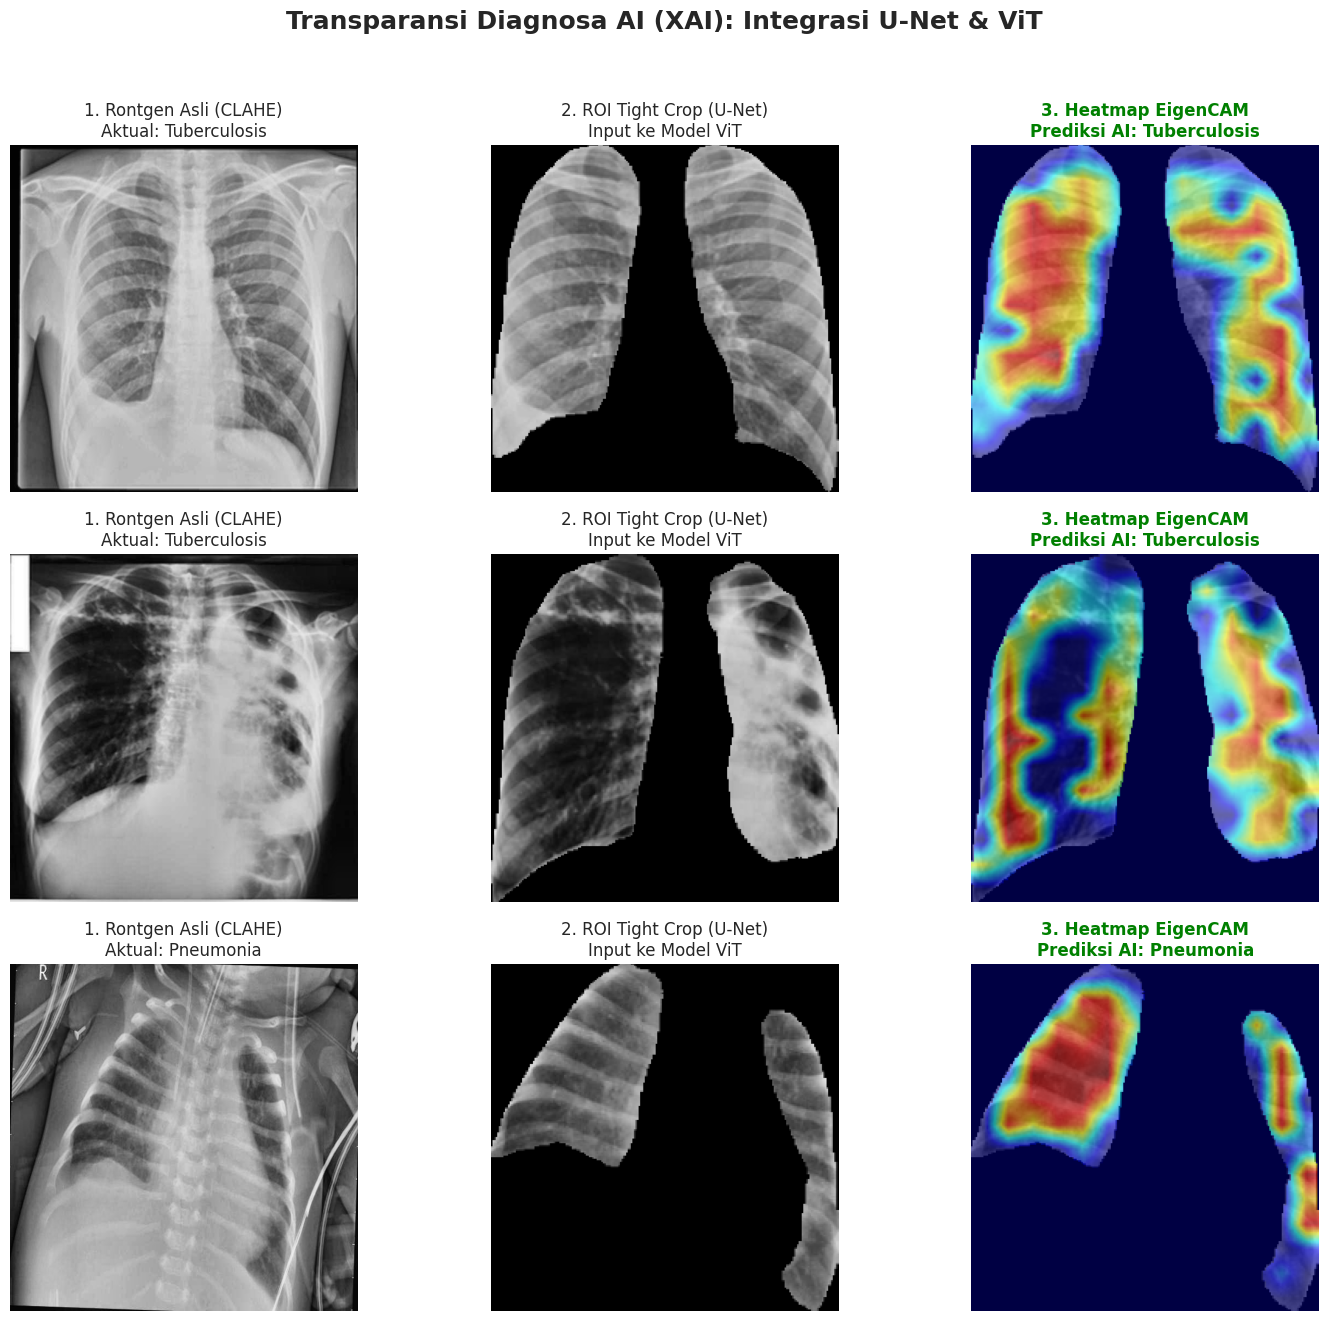

In [17]:
print("=== 11. EXPLAINABLE AI (XAI) - ViT EigenCAM + U-NET TIGHT CROP (STANDALONE) ===")

# Pastikan library grad-cam sudah terinstall di Kaggle:
# !pip install grad-cam
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==============================================================
# 1. SETUP MODEL & LOAD BOBOT TERBAIK
# ==============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pastikan path ini sesuai dengan file .pth yang ada di folder /kaggle/working kamu
PATH_UNET = "/kaggle/working/unet_paru_lr_1e4_best.pth"
PATH_VIT = "/kaggle/working/vit_skripsi_multiclass_bestV2.pth"

# Load bobot ke dalam arsitektur
model_unet.load_state_dict(torch.load(PATH_UNET, map_location=device))
model_vit.load_state_dict(torch.load(PATH_VIT, map_location=device))

model_unet.eval()
model_vit.eval()

print("[*] Bobot U-Net dan ViT terbaik berhasil dimuat ke memori!")

# ==============================================================
# 2. FUNGSI TRANSFORMASI & SETUP EIGENCAM ViT
# ==============================================================
# Fungsi membongkar 196 token ViT kembali menjadi gambar spasial 14x14
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# Target Layer: Layer Normalisasi (ln_1) dari blok Transformer terakhir
target_layers = [model_vit.transformer_encoder.layers[-1].ln_1]

# Gunakan EigenCAM
cam = EigenCAM(model=model_vit, 
               target_layers=target_layers, 
               reshape_transform=reshape_transform)

idx_to_class = {0: 'Normal', 1: 'Pneumonia', 2: 'Tuberculosis'}

# ==============================================================
# 3. PROSES INFERENSI & VISUALISASI XAI
# ==============================================================
num_test = 3 # Jumlah gambar yang divisualisasikan
sample_indices = random.sample(range(len(val_imgs)), num_test)

fig, axes = plt.subplots(num_test, 3, figsize=(15, 4.5 * num_test))
fig.suptitle("Transparansi Diagnosa AI (XAI): Integrasi U-Net & ViT", fontsize=18, fontweight='bold', y=0.98)

for i, idx in enumerate(sample_indices):
    img_path = val_imgs[idx]
    true_label = idx_to_class[val_labels[idx]]
    
    # A. LOAD GAMBAR ASLI
    img_pil = Image.open(img_path).convert("RGB")
    
    # B. PROSES U-NET MASKING
    unet_input = img_pil.resize((256, 256))
    unet_arr = np.transpose(np.array(unet_input, dtype=np.float32) / 255.0, (2, 0, 1))
    unet_tensor = torch.tensor(unet_arr).unsqueeze(0).to(device)
    
    with torch.no_grad():
        _, pred_mask = torch.max(model_unet(unet_tensor), 1)
        pred_mask_np = pred_mask.squeeze(0).cpu().numpy()
        
    binary_mask = (pred_mask_np > 0).astype(np.uint8)
    mask_pil = Image.fromarray(binary_mask * 255).resize(img_pil.size, Image.Resampling.NEAREST)
    mask_np_2d = np.array(mask_pil) / 255.0
    mask_np_3d = np.expand_dims(mask_np_2d, axis=-1)
    
    # C. ISOLASI ROI & TIGHT CROP (Seperti di DataLoader Cell 7)
    img_np = np.array(img_pil)
    masked_img_np = (img_np * mask_np_3d).astype(np.uint8)
    
    coords = np.argwhere(mask_np_2d > 0)
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        # Potong presisi seukuran paru
        cropped_masked_img = masked_img_np[y_min:y_max+1, x_min:x_max+1]
        cropped_mask = mask_np_2d[y_min:y_max+1, x_min:x_max+1]
    else:
        cropped_masked_img = masked_img_np
        cropped_mask = mask_np_2d
        
    # Resize crop ke ukuran standar ViT (224x224)
    img_224 = cv2.resize(cropped_masked_img, (224, 224))
    mask_224 = cv2.resize(cropped_mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    
    # D. INFERENSI ViT & GENERATE HEATMAP
    img_224_pil = Image.fromarray(img_224)
    # Pastikan val_dataset_vit.vit_transform tersedia di memori (sudah di-run di Cell 7)
    vit_tensor = val_dataset_vit.vit_transform(img_224_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_logits = model_vit(vit_tensor)
        pred_idx = torch.argmax(pred_logits, dim=1).item()
        pred_label = idx_to_class[pred_idx]
    
    # Generate Heatmap EigenCAM
    grayscale_cam = cam(input_tensor=vit_tensor, targets=None)[0, :]
    
    # Kalikan heatmap dengan mask paru U-Net
    grayscale_cam_masked = grayscale_cam * mask_224
    
    # Timpa heatmap ke atas gambar crop paru
    rgb_img_float = np.float32(img_224) / 255.0
    cam_image = show_cam_on_image(rgb_img_float, grayscale_cam_masked, use_rgb=True)
    
    # E. PLOTTING VISUALISASI KE LAYAR
    axes[i, 0].imshow(img_pil)
    axes[i, 0].set_title(f"1. Rontgen Asli (CLAHE)\nAktual: {true_label}", fontsize=12)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(img_224)
    axes[i, 1].set_title(f"2. ROI Tight Crop (U-Net)\nInput ke Model ViT", fontsize=12)
    axes[i, 1].axis('off')
    
    color_title = 'green' if true_label == pred_label else 'red'
    axes[i, 2].imshow(cam_image)
    axes[i, 2].set_title(f"3. Heatmap EigenCAM\nPrediksi AI: {pred_label}", fontsize=12, color=color_title, fontweight='bold')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()